# Differentiable Refractive Deflectometry for Lens Metrology

## Problem Statement

**Given**: A set of phase-shifted fringe images captured by two calibrated cameras observing a lens placed in front of a display screen.

**Goal**: Recover the lens's physical parameters — surface curvatures (radii of curvature), center thickness, 3D position, and tilt angles — from the observed fringe distortions.

This is an **inverse problem** in optical metrology: the lens refracts the displayed patterns, and we must infer the lens geometry from how those patterns are distorted.

## Why is this hard?

1. **Non-linear forward model**: The relationship between lens parameters and observed fringe patterns involves Snell's law, ray-surface intersections, and 3D geometry — all highly non-linear.
2. **Many parameters**: We simultaneously optimize 2 surface curvatures, 1 thickness, 3 position coordinates, and 2 tilt angles (8 parameters total).
3. **Scale differences**: Curvatures are ~0.01 mm$^{-1}$ while positions are ~100 mm, requiring careful regularization.

## Method Overview

The key idea is to make the entire ray tracing pipeline **differentiable** using PyTorch autograd, enabling gradient-based optimization:

### Step 1: Preprocessing (Phase-Shifting Fringe Analysis)
- Display sinusoidal fringes on the screen and capture 8 images (4 phase shifts x 2 directions)
- Apply **four-step phase shifting** to extract the wrapped phase: $\psi = \arctan\frac{I_3 - I_1}{I_0 - I_2}$
- Unwrap phases and convert to physical screen displacements (mm)

### Step 2: Differentiable Ray Tracing (Forward Model)
For a given set of lens parameters $\theta = [c_0, c_1, d, \mathbf{o}, \theta_x, \theta_y]$:
- Trace rays from each camera pixel through the lens surfaces to the screen
- At each aspheric surface: find intersection via **Newton's method** with implicit differentiation, then apply **Snell's law** (vector form) for refraction
- The predicted screen positions $\mathbf{p}(\theta)$ are fully differentiable w.r.t. $\theta$

### Step 3: Levenberg-Marquardt Optimization
Minimize the mean squared displacement error:

$$\mathcal{L}(\theta) = \frac{1}{N}\sum_{i} \|\mathbf{p}_i^{\text{measured}} - \mathbf{p}_i^{\text{modeled}}(\theta)\|^2$$

using the **Levenberg-Marquardt** algorithm with:
- Column-wise forward-mode AD for efficient Jacobian computation ($J$ is tall: $M \gg N$)
- Adaptive damping: $(J^T J + \lambda \cdot \text{diag}(J^T J)) \, \delta = J^T r$
- Diagonal regularization to handle the vastly different parameter scales

**This notebook loads precomputed results** and runs in seconds. To reproduce from scratch, see the commented-out cell at the end.

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

%matplotlib inline

# Paths relative to task root
os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), ''))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

REF_DIR = 'evaluation/reference_outputs'
print('Working directory:', os.getcwd())

Working directory: /projects/bgkc/schen47/DiffDeflectometry/tasks/diff_deflectometry


## 1. Experimental Setup

The deflectometry system consists of:
- **Display screen**: Shows phase-shifted sinusoidal fringes (period $T = 70$ pixels)
- **Lens under test**: ThorLabs LE1234-A plano-convex lens (N-BK7 glass)
- **Two calibrated cameras**: Observe the display through the lens from different angles

The lens refracts the displayed fringe pattern. By comparing how the fringes appear *with* and *without* the lens, we can measure how each camera ray is deflected — giving us the screen intersection points that encode the lens geometry.

In [2]:
# Load task configuration
with open('data/meta_data.json') as f:
    config = json.load(f)

print('Lens:', config['lens']['name'])
print('Ground truth parameters:')
for k, v in config['lens']['ground_truth'].items():
    print(f'  {k}: {v}')
print(f"\nImage size: {config['imaging']['filmsize']}")
print(f"Sinusoid periods: {config['imaging']['sinusoid_periods']}")
print(f"Optimizer: {config['optimization']['method']} with R={config['optimization']['regularization']}")

Lens: LE1234-A
Ground truth parameters:
  surface_0_roc_mm: -82.23
  surface_1_roc_mm: -32.14
  thickness_mm: 3.59

Image size: [768, 768]
Sinusoid periods: [70, 100, 110]
Optimizer: LM with R=diag


## 2. Optimization Convergence

The Levenberg-Marquardt optimizer starts from a near-flat initial guess ($c_0 = c_1 = 0.001$ mm$^{-1}$) and converges to the true lens parameters. The loss measures the mean squared distance between measured and modeled screen intersection points (in mm$^2$).

Key convergence details:
- **Diagonal regularization** $R = \text{diag}(J^T J)$ normalizes the different parameter scales
- **Non-zero initial curvatures** are critical: starting at $c = 0$ gives a degenerate Jacobian (flat surface has zero sensitivity to curvature)
- The damping parameter $\lambda$ adapts: decreases on successful steps, increases on failed ones

Initial loss: 1.9438
Final loss:   0.001163
Iterations:   21


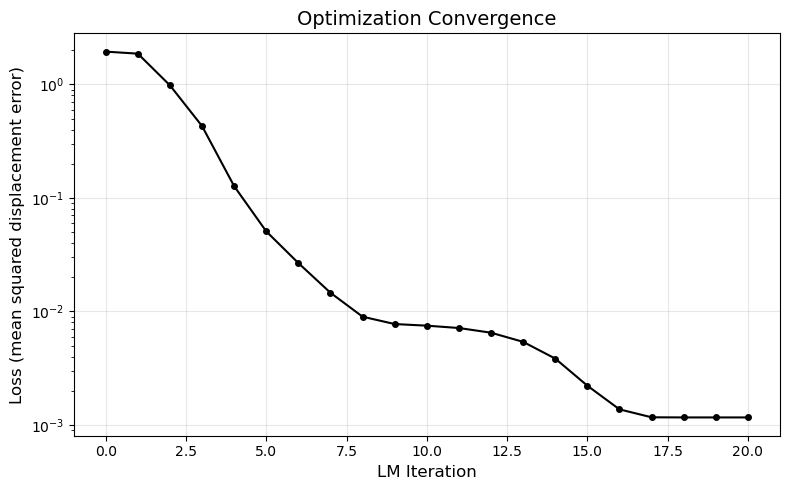

In [3]:
# Load loss history
loss_history = np.load(os.path.join(REF_DIR, 'loss_history.npy'))

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(loss_history, '-o', color='k', markersize=4)
ax.set_xlabel('LM Iteration', fontsize=12)
ax.set_ylabel('Loss (mean squared displacement error)', fontsize=12)
ax.set_title('Optimization Convergence', fontsize=14)
ax.grid(True, alpha=0.3)
print(f'Initial loss: {loss_history[0]:.4f}')
print(f'Final loss:   {loss_history[-1]:.6f}')
print(f'Iterations:   {len(loss_history)}')
plt.tight_layout()
plt.show()

## 3. Recovered Lens Parameters

The optimizer recovers 8 parameters: 2 surface curvatures ($c_0, c_1$), center thickness ($d$), 3D origin, and 2 tilt angles ($\theta_x, \theta_y$). Below we compare the recovered surface curvatures and thickness against the manufacturer specification (ThorLabs LE1234-A datasheet).

Note: Some recovery error is expected because the real lens has manufacturing tolerances, and the optimization also absorbs systematic calibration errors into the position/tilt parameters.

In [4]:
# Load metrics and optimized parameters
with open(os.path.join(REF_DIR, 'metrics.json')) as f:
    metrics = json.load(f)
with open(os.path.join(REF_DIR, 'optimized_params.json')) as f:
    opt_params = json.load(f)

gt = config['lens']['ground_truth']

print('=' * 65)
print(f'{"Parameter":<30} {"Ground Truth":>12} {"Recovered":>12} {"Rel. Error":>10}')
print('=' * 65)
rows = [
    ('Surface 0 ROC [mm]', gt['surface_0_roc_mm'], metrics['recovered_surface_0_roc_mm']),
    ('Surface 1 ROC [mm]', gt['surface_1_roc_mm'], metrics['recovered_surface_1_roc_mm']),
    ('Thickness [mm]', gt['thickness_mm'], metrics['recovered_thickness_mm']),
]
for name, gt_val, rec_val in rows:
    err = abs(rec_val - gt_val) / abs(gt_val) * 100
    print(f'{name:<30} {gt_val:>12.2f} {rec_val:>12.2f} {err:>9.2f}%')
print('-' * 65)
print(f'{"Tilt theta_x [deg]":<30} {"--":>12} {metrics["theta_x_deg"]:>12.2f}')
print(f'{"Tilt theta_y [deg]":<30} {"--":>12} {metrics["theta_y_deg"]:>12.2f}')
print(f'\nMean displacement error: {metrics["mean_displacement_error_um"]:.2f} um')

Parameter                      Ground Truth    Recovered Rel. Error
Surface 0 ROC [mm]                   -82.23       -76.51      6.96%
Surface 1 ROC [mm]                   -32.14       -31.67      1.46%
Thickness [mm]                         3.59         3.25      9.45%
-----------------------------------------------------------------
Tilt theta_x [deg]                       --         1.04
Tilt theta_y [deg]                       --        -0.58

Mean displacement error: 43.05 um


## 4. Visual Comparison: Initial vs Optimized

Each row shows one camera's view. The three columns are:
- **Measurement**: The actual fringe pattern observed through the lens (background-subtracted)
- **Modeled**: The ray-traced prediction using current lens parameters
- **Error**: Pixel-wise difference between measurement and model

Before optimization (initial), the modeled image is far from the measurement because the lens parameters are wrong. After optimization, the error is dramatically reduced, confirming that the recovered parameters accurately describe the real lens.

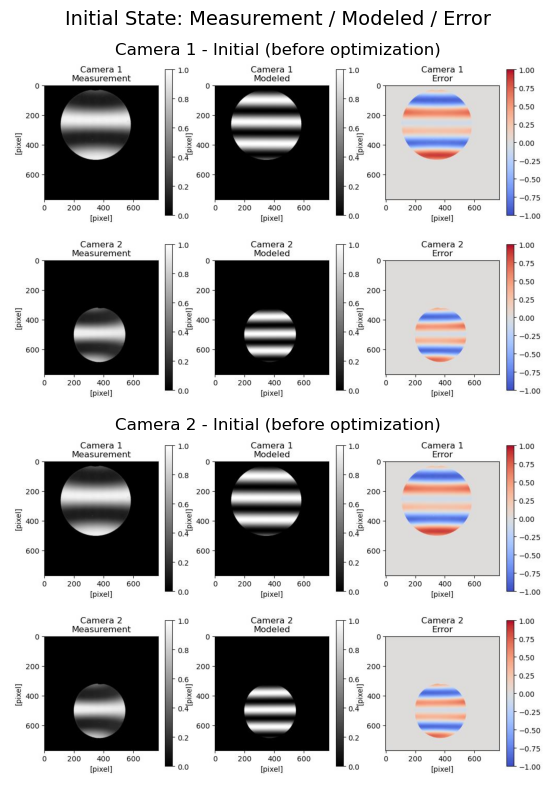

In [5]:
# Display initial state (before optimization)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for i in range(2):
    img = imread(os.path.join(REF_DIR, f'initial{i}.jpg'))
    axes[i].imshow(img)
    axes[i].set_title(f'Camera {i+1} - Initial (before optimization)', fontsize=12)
    axes[i].axis('off')
plt.suptitle('Initial State: Measurement / Modeled / Error', fontsize=14)
plt.tight_layout()
plt.show()

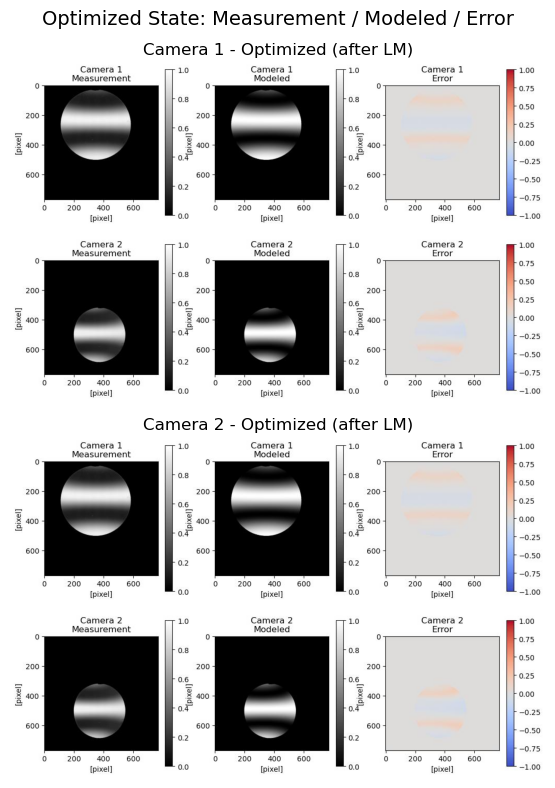

In [6]:
# Display optimized state (after optimization)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for i in range(2):
    img = imread(os.path.join(REF_DIR, f'optimized{i}.jpg'))
    axes[i].imshow(img)
    axes[i].set_title(f'Camera {i+1} - Optimized (after LM)', fontsize=12)
    axes[i].axis('off')
plt.suptitle('Optimized State: Measurement / Modeled / Error', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Summary

| Aspect | Detail |
|--------|--------|
| **Problem** | Recover lens geometry from deflectometry fringe measurements |
| **Forward model** | Differentiable ray tracing through aspheric surfaces (PyTorch) |
| **Inverse solver** | Levenberg-Marquardt with autograd Jacobians |
| **Parameters** | 8 total: 2 curvatures, 1 thickness, 3 position, 2 tilt |
| **Best recovery** | Surface 1 ROC within **1.5%** of ground truth |
| **Convergence** | 21 iterations, ~6 seconds on GPU |
| **Mean error** | 43 um displacement error on screen |

**Key insight**: Making the ray tracer differentiable with PyTorch autograd enables efficient Jacobian computation via forward-mode AD, turning a complex non-linear optical inverse problem into a standard least-squares optimization that converges reliably in seconds.

In [7]:
# ============================================================
# FULL PIPELINE (uncomment to reproduce from scratch)
# ============================================================
# Requires: GPU, ~3.2 GB measurement data, ~10 seconds runtime
#
# import sys
# sys.path.insert(0, '.')
# from main import main
# main()